### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS = [
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-23_10:17:41.012941',
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-23_09:30:04.478510',
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-22_17:18:53.835742',
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-22_17:07:55.363681',
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-22_16:07:39.377836',
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-22_15:55:29.694723',
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-22_15:49:20.646941',
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-22_15:23:45.453520',
    '_hardcoded_dc_input_tanh_no_noise_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-22_12:51:41.808416',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_17:13:11.786346',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_17:09:04.898659',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_17:05:05.776287',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_16:59:41.386630',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_16:51:32.070759',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_16:46:59.196851',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_16:40:15.732530',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_16:32:31.592947',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_16:23:31.609487',
    '_hardcoded_dc_input_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_16:18:46.980126',
    '_experiment_w_hardcoded_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_15:52:57.110476',
    '_experiment_w_hardcoded_tanh_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-21_15:42:09.961394',
    '_experiment_w_hardcoded_150ms_holding_period_40_train_decoder_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-16_16:45:21.425296',
    '_experiment_w_hardcoded_150ms_holding_period_40_train_decoder_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-16_14:48:04.303730',
    '_experiment_w_hardcoded_150ms_holding_period_40_train_decoder_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-16_13:41:31.562008',
    '_experiment_w_hardcoded_150ms_holding_period_40_train_decoder_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-16_13:33:12.750080',
    '_experiment_w_hardcoded_150ms_holding_period_40_train_decoder_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-16_13:26:37.013110',
    '_experiment_w_hardcoded_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-16_12:00:19.023497',
    '_experiment_w_hardcoded_long_holding_period_hard_coded_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8015_2025-07-16_12:43:15.319106',
]

DATA_PATHS = [ './sims_out/' + d for d in DATA_PATHS]

In [2]:
def load_numpy(data_path):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

### Analysis of neural activity

In [3]:
def load_r_and_int_values(rule_path, net_path, last_n=100):
    all_r = np.stack(load_numpy(os.path.join(rule_path, 'activities', net_path)))
    all_int_values = np.stack(load_numpy(os.path.join(rule_path, 'integrated_values', net_path)))
    
    if last_n is not None:
        last_n_r = all_r[-last_n:, 200:, :15]
        all_int_values = all_int_values[-last_n:, :]
    else:
        last_n_r = all_r[:, 200:, :15]
        
    last_n_r = np.transpose(last_n_r, [2, 0, 1])

    return last_n_r, all_int_values

Do PCA on last 50 trials, 15 units in ellipsoid body.

In [4]:
def fit_pca(last_100_r):
    flattened_data = last_100_r.reshape(last_100_r.shape[0], last_100_r.shape[1] * last_100_r.shape[2], order='C')
    pca = PCA()
    pc_activities = pca.fit_transform(flattened_data.T)
    pc_activities = pc_activities.T.reshape(last_100_r.shape, order='C')

    return pc_activities, pca

Learned structure leads to low dimensional activity.

In [ ]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

explained_variance_ratios = pca.explained_variance_ratio_
axs.bar(np.arange(explained_variance_ratios.shape[0]), explained_variance_ratios)
axs.set_xlim(-0.75, 10)
axs.set_ylabel('Variance explained')
axs.set_xlabel('PC')
format_plot(axs)

Retrieve target integrated sums. Keep only the last 100 trials.

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


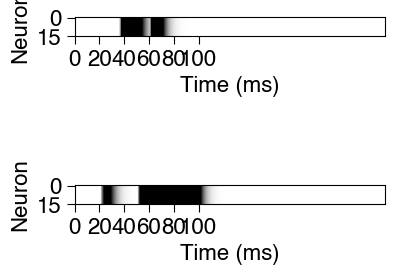

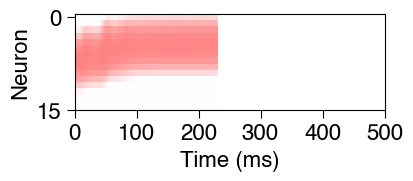

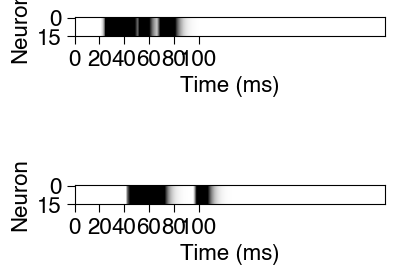

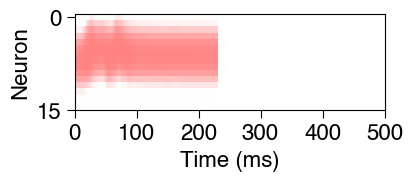

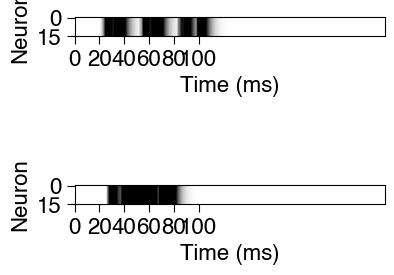

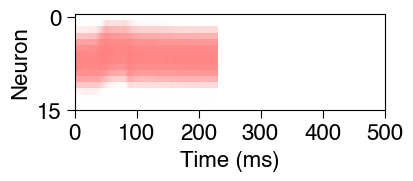

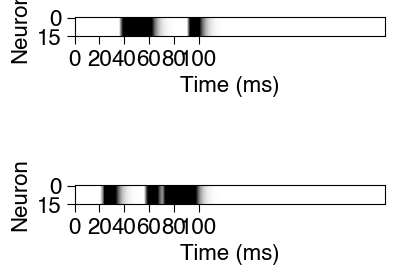

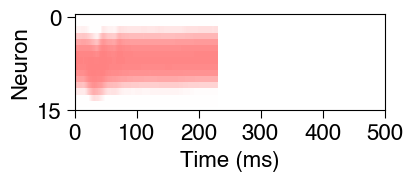

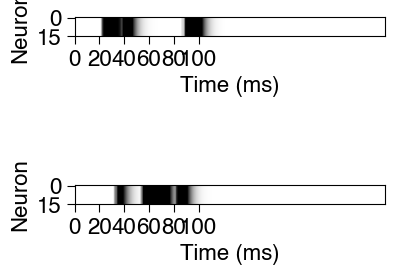

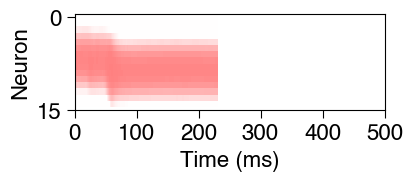

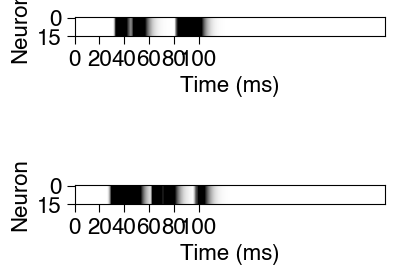

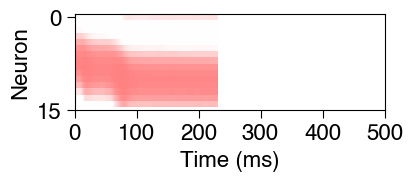

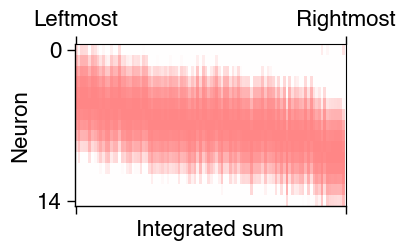

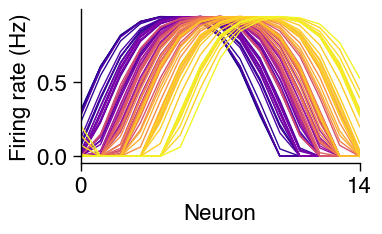

In [7]:
def make_tuning_curves(last_100_r, all_int_values):
scale = 4

inputs_raw = load_numpy(os.path.join(DATA_PATHS[0], 'inputs/net_001_*.npy'))
inputs = np.concatenate([np.zeros((100, 200, 30)), np.stack(inputs_raw[-100:])], axis=1)

ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))

for i, j in enumerate(np.argsort(all_int_values[:, -1])):
    
    if i % 20 == 0 or i == len(all_int_values[:, -1]) - 1:
        fig, axs = plt.subplots(2, 1, figsize=(1 * scale, 1 * scale))
        axs[0].matshow(inputs[j, :, :15].T, cmap='binary', vmin=0, vmax=5, aspect=10)
        axs[1].matshow(inputs[j, :, 15:].T, cmap='binary', vmin=0, vmax=5, aspect=10)
        for k in range(2):
            axs[k].set_xlabel('Time (ms)', fontsize=16)
            axs[k].set_ylabel('Neuron', fontsize=16)
            axs[k].set_xticks(np.arange(0, 1001, 200), (np.arange(0, 1001, 200) / 10).astype(int))
            axs[k].set_yticks([0, 15])
            axs[k].tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
            axs[k].xaxis.set_label_position('bottom')
            axs[k].tick_params(axis='both', length=6, labelsize=16)

        fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
        axs.matshow(last_100_r[:, j, :], cmap='bwr', vmin=-2, vmax=2, aspect=100)
        axs.set_xlabel('Time (ms)', fontsize=16)
        axs.set_ylabel('Neuron', fontsize=16)
        axs.set_xticks(np.arange(0, 5001, 1000), (np.arange(0, 5001, 1000) / 10).astype(int))
        axs.set_yticks([0, 15])
        axs.tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
        axs.xaxis.set_label_position('bottom')
        axs.tick_params(axis='both', length=6, labelsize=16)
    
for i, j in enumerate(np.argsort(all_int_values[:, -250])):
    ending_states[:, i] = last_100_r[:, j, -250]
    
#     fig.savefig(os.path.join(img_path, f'act_{zero_pad(run, 4)}_t_{zero_pad(timestep, 4)}.png'))
#     plt.close()

scale = 3.5
fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
axs.matshow(ending_states, cmap='bwr', vmin=-2, vmax=2, aspect=4)

format_plot(axs, rightspine=True, topspine=True)

axs.set_xlabel('Integrated sum', fontsize=16)
axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
axs.set_ylabel('Neuron', fontsize=16)
axs.set_yticks([0, 14])
axs.tick_params(axis='both', length=6, labelsize=16)

scale = 2
fig, axs = plt.subplots(1, 1, figsize=(1.8 * scale, 1 * scale))

import matplotlib.pyplot as plt
import numpy as np

plasma = plt.get_cmap("plasma")
colors = [plasma(i / 100)[:3] for i in range(100)]  # 49 to include 0 and 1

for i in range(ending_states.shape[1]):
    axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

format_plot(axs)

axs.set_ylabel('Firing rate (Hz)', fontsize=16)
axs.set_xlabel('Neuron', fontsize=16)
axs.set_xticks([0, 14])
axs.set_xlim(0, 14)
axs.tick_params(axis='both', length=6, labelsize=16)
    

In [8]:
def make_tuning_curves(last_100_r, all_int_values):
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    int_values_for_ending_states = np.empty((all_int_values.shape[0]))
    for i, j in enumerate(np.argsort(all_int_values[:, -250])):
        ending_states[:, i] = last_100_r[:, j, -250]
        int_values_for_ending_states[i] = all_int_values[j, -250]
    
    scale = 3.5
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    axs.matshow(ending_states, cmap='bwr', vmin=-2, vmax=2, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum', fontsize=16)
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron', fontsize=16)
    axs.set_yticks([0, 14])
    axs.tick_params(axis='both', length=6, labelsize=16)
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1.8 * scale, 1 * scale))
    
    plasma = plt.get_cmap("plasma")
    int_min, int_max = int_values_for_ending_states.min(), int_values_for_ending_states.max()
    colors = [plasma((int_values_for_ending_states[i] - int_min) / (int_max - int_min))[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)', fontsize=16)
    axs.set_xlabel('Neuron', fontsize=16)
    axs.set_xticks([0, 14])
    axs.set_xlim(0, 14)
    axs.tick_params(axis='both', length=6, labelsize=16)

In [78]:
from matplotlib import gridspec

def make_stability_plot(last_100_r, all_int_values):
    scale = 4

    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

    def normed_loc(raster):
        total_activity = raster.sum(axis=0)
        raster_normed = np.divide(
            raster,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster)
        )
        ordered_indices = np.argsort(raster, axis=0)
        max_5_indices = ordered_indices[-13:, :]
        x = np.arange(raster_normed.shape[0])
        cols = np.arange(raster.shape[1])[None, :]
        locs = np.einsum(
            'ij,ij->j',
            x[max_5_indices],
            raster_normed[max_5_indices, cols],
        )
        return locs

    all_final_traj = []

    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(2.5 * scale, 1 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        traj = normed_loc(last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        ax_main.scatter(
            np.arange(all_int_values.shape[1]),
            traj,
            alpha=0.2,
            c=all_int_values[j, :],
            s=0.05,
            cmap='plasma'
        )

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)', fontsize=16)
    ax_main.set_ylabel('Bump location', fontsize=16)
    ax_main.set_xticks(np.arange(0, 1301, 1000))
    ax_main.set_xticklabels((np.arange(0, 1301, 1000) / 10).astype(int))
    ax_main.set_yticks([0, 15], [0, 15])
    ax_main.set_ylim(-1, 16)
    ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main)

    # Histogram on the right (rotated)
    ax_hist.hist(all_final_traj, bins=30, orientation='horizontal', color='gray')
    ax_hist.set_xlabel('Count', fontsize=16)
    ax_hist.tick_params(axis='x', labelsize=14)
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-axis labels to avoid duplication
    format_plot(ax_hist)

    plt.show()

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


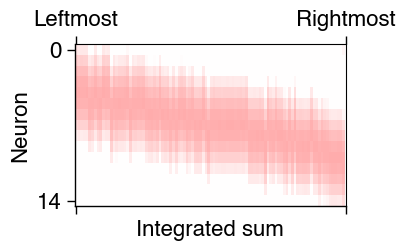

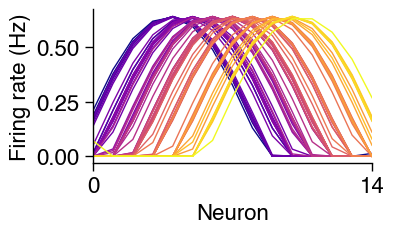

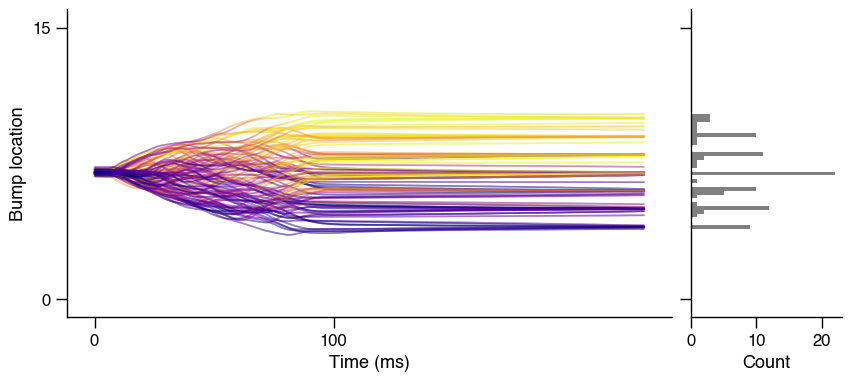

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


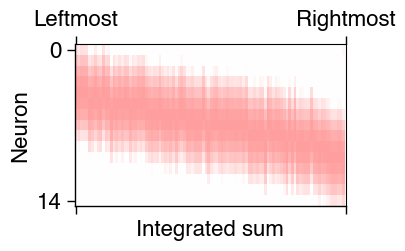

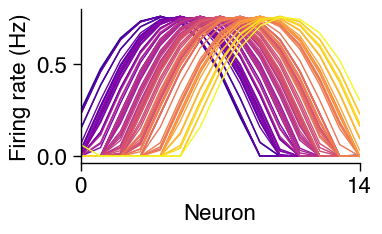

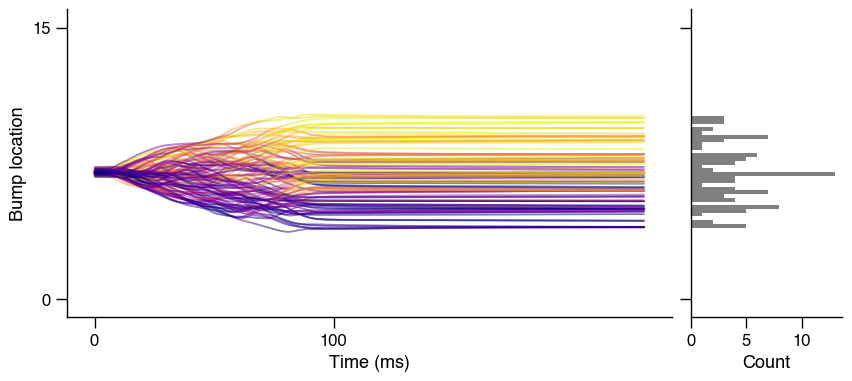

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


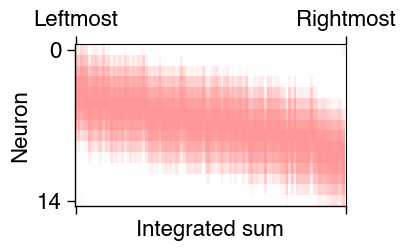

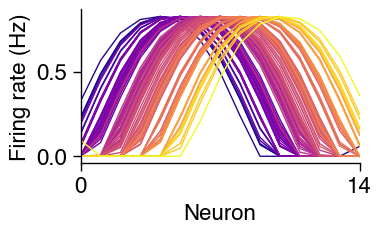

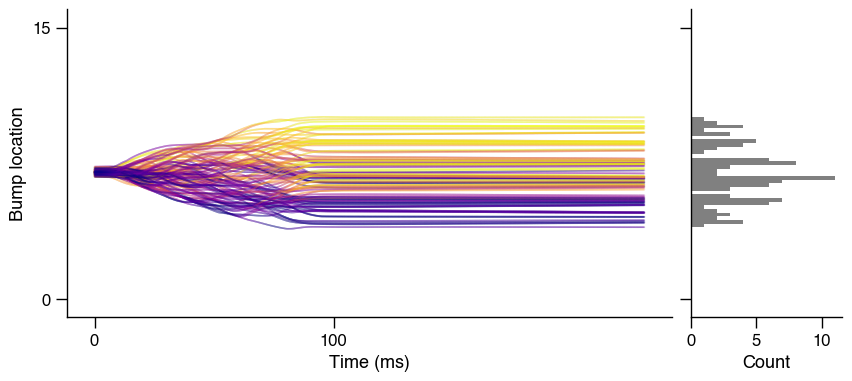

In [79]:
for dp in DATA_PATHS[:3]:
    for i in range(1):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy')
        make_tuning_curves(last_100_r, all_int_values)
        make_stability_plot(last_100_r, all_int_values)

In [20]:
def test_representation_fidelity(all_r, all_int_values):

    train_range = slice(0, 40)
    test_range = slice(40, 140)
    
    stacked_activities_train = all_r[:, train_range, :]
    y_train = all_int_values[train_range, :]
    stacked_activities_test = all_r[:, test_range, :]
    y_test = all_int_values[test_range, :]
    
    scores = []
    
    for i in range(20):
        train_acts = np.random.randint(0, 40, size=1000)
        train_steps = np.random.randint(0, 2250, size=1000)
        test_acts = np.arange(100)
        test_steps = np.random.randint(0, 2250, size=100)
        
        X_train = stacked_activities_train[:, train_acts, train_steps + 50].T
        Y_train = y_train[train_acts, train_steps]
        
        X_test = stacked_activities_test[:, test_acts, test_steps + 50].T
        Y_test = y_test[test_acts, test_steps]
        
        reg = LinearRegression().fit(X_train, Y_train)
        score = reg.score(X_test, Y_test)
        scores.append(score)
    
    print(scores)
    print(np.mean(scores))

    scale = 0.8
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

    Y_hat = reg.predict(X_test)

    m = 1.05 * np.max(np.abs(np.concatenate([Y_test, Y_hat])))
    
    axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(Y_test, Y_hat, s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
    axs.set_xlim(-m, m)
    axs.set_ylim(-m, m)
    axs.set_xticks([-100, 0, 100])
    axs.set_yticks([-100, 0, 100])
    
    format_plot(axs)
    
    axs.set_xlabel(r'$y$', fontsize=16)
    axs.set_ylabel(r'$\hat{y}$', fontsize=16)
    axs.set_title('Predicted vs true integrated sums', fontsize=16)
    axs.tick_params(axis='both', length=6, labelsize=16)

[0.903177170685551, 0.9314026010254661, 0.8784527910751937, 0.9068527995362823, 0.9068072035498005, 0.8981885142498004, 0.9032522426026137, 0.9013863622101566, 0.8942495570338833, 0.9213539099018011, 0.8993158295694826, 0.9158254234419354, 0.9109797025108194, 0.9077019376897919, 0.9112389033325927, 0.8957580008083033, 0.9174869550122633, 0.9021871680949907, 0.9122321902602387, 0.9159589706058642]
0.9066904116598415
Axes(0.125,0.11;0.775x0.77)
[0.9156023804955304, 0.9127555641845784, 0.9261247461547044, 0.9205324817742008, 0.9288307420497945, 0.9176450574905752, 0.9412573876199455, 0.9224990818631671, 0.9236581672096871, 0.9255592490174797, 0.919697163167986, 0.9165944391836085, 0.920580860631342, 0.9192104515341274, 0.9201929556728495, 0.9299365883469042, 0.9215381068458128, 0.9206592666518663, 0.9152222524826937, 0.9290983715781017]
0.9223597656977477
Axes(0.125,0.11;0.775x0.77)
[0.9246935428323984, 0.9263465948979508, 0.9240594856423868, 0.9269731123293039, 0.927334180491451, 0.92026

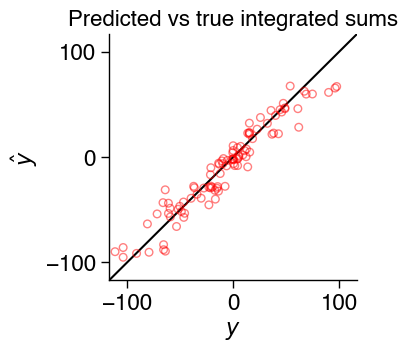

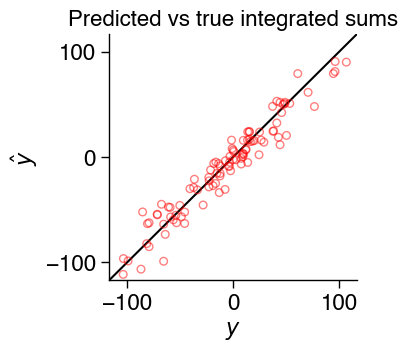

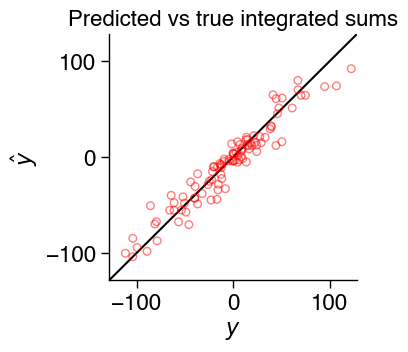

In [21]:
for dp in DATA_PATHS[:3]:
    for i in range(1):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        test_representation_fidelity(all_r, all_int_values)